# Dynamic Pricing & Elasticity Optimization — Analysis Notebook

**AquaPure Systems (synthetic).** This notebook walks through the full pipeline: synthetic data generation, the log-log elasticity model, K-Means segmentation, constrained price optimization, and business recommendations.

> Synthetic data only — no real company data. See README for the disclaimer.

In [1]:
import sys, os
# Make the src package importable when running from notebooks/
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
import pandas as pd
pd.set_option('display.max_columns', None)
from src import (config, data_generation, preprocessing, elasticity_model,
                 segmentation, optimization, recommendations, visualization)
print('Company:', config.SYNTHETIC_COMPANY_NAME)

Company: AquaPure Systems


## 1. Generate & preprocess the synthetic panel

In [2]:
data_generation.generate_and_save()
df = preprocessing.preprocess()
df.head()

[data_generation] Wrote 27,000 rows -> /sessions/gifted-magical-shannon/mnt/Pricing/dynamic-pricing-elasticity/data/synthetic_pricing_data.csv
[preprocessing] 27,000 clean rows, 30 columns


,date,year,month,period,region,customer_segment,product_category,product_id,units_sold,list_price,net_price,discount_pct,cost_per_unit,gross_margin_pct,revenue,gross_profit,marketing_campaign_flag,marketing_spend,competitor_price_index,category_market_index,inflation_index,season_index,order_frequency,_true_elasticity,log_units,log_net_price,log_competitor_index,log_category_index,log_inflation,log_season
0,2023-01-01,2023,1,1,North,Homeowners,Residential Filters,RES-001,842,232.56,228.45,0.0177,146.71,0.3578,192356.55,68828.36,0,0.00,1.0184,1.0559,0.9983,0.8200,6.230,-1.6731,6.735780,5.431317,0.018233,0.054393,-0.001701,-0.198451
1,2023-02-01,2023,2,2,North,Homeowners,Residential Filters,RES-001,1290,217.74,200.90,0.0773,146.71,0.2697,259161.80,69908.40,1,3585.32,1.0203,1.0426,1.0055,0.8441,5.390,-1.6731,7.162397,5.302807,0.020097,0.041718,0.005485,-0.169484
2,2023-03-01,2023,3,3,North,Homeowners,Residential Filters,RES-001,1261,232.98,207.35,0.1100,146.71,0.2925,261465.36,76466.49,0,0.00,1.0026,1.0314,0.9982,0.9100,4.637,-1.6731,7.139660,5.334408,0.002597,0.030917,-0.001802,-0.094311
3,2023-04-01,2023,4,4,North,Homeowners,Residential Filters,RES-001,926,246.23,225.18,0.0855,146.71,0.3485,208513.76,72662.09,0,0.00,1.0181,1.0293,1.0059,1.0000,3.463,-1.6731,6.830874,5.416900,0.017938,0.028879,0.005883,0.000000
4,2023-05-01,2023,5,5,North,Homeowners,Residential Filters,RES-001,1436,222.03,214.90,0.0321,146.71,0.3173,308600.42,97927.64,0,0.00,1.0167,1.0621,1.0066,1.0900,4.080,-1.6731,7.269617,5.370173,0.016562,0.060248,0.006578,0.086178


In [3]:
df[['units_sold','net_price','discount_pct','revenue','gross_profit']].describe().round(2)

,units_sold,net_price,discount_pct,revenue,gross_profit
count,27000.00,27000.00,27000.00,27000.00,27000.00
mean,658.75,4650.48,0.07,1872959.46,791289.55
std,404.11,6656.84,0.04,2693679.93,1130128.88
min,99.00,54.75,0.00,20506.52,10169.72
25%,362.00,189.16,0.04,125380.96,51882.64
50%,554.00,1230.02,0.07,659497.82,349916.06
75%,849.00,4482.01,0.10,2537113.96,973807.33
max,3920.00,24546.95,0.25,21659864.57,9796348.47


## 2. Estimate price elasticity (log-log model with fixed effects)
The coefficient on `log(net_price)` is the own-price elasticity of demand.

In [4]:
results_df, seg_region_df, overall = elasticity_model.run_elasticity(df)
print(f"Overall elasticity: {overall['elasticity']:.3f} "
      f"(R^2={overall['r_squared']:.3f}, n={overall['n_obs']:,})")
results_df[['scope','group','elasticity','std_error','p_value','is_elastic']].round(3)

[elasticity_model] overall elasticity = -1.050 (R^2=0.879, n=27,000)
Overall elasticity: -1.050 (R^2=0.879, n=27,000)


,scope,group,elasticity,std_error,p_value,is_elastic
0,overall,ALL,-1.050,0.008,0.0,True
1,customer_segment,Distributors,-1.188,0.017,0.0,True
2,customer_segment,Homeowners,-1.412,0.017,0.0,True
3,customer_segment,Industrial Accounts,-0.784,0.016,0.0,False
4,customer_segment,Municipal,-0.811,0.016,0.0,False
5,customer_segment,Small Business,-1.097,0.016,0.0,True
6,region,Midwest,-0.970,0.015,0.0,False
7,region,North,-0.785,0.017,0.0,False
8,region,Northeast,-0.939,0.016,0.0,False
9,region,South,-1.153,0.018,0.0,True


## 3. K-Means customer segmentation

In [5]:
profiles = segmentation.run_segmentation(df)
profiles[['customer_segment','region','cluster','cluster_name',
          'avg_discount_received','avg_net_price','gross_margin_contribution']].round(2).head(10)

[segmentation] 4 clusters over 25 customer cells: ['Low-Volume Opportunistic Buyers', 'Premium / Service-Oriented Buyers', 'Promotion-Responsive Buyers', 'Stable High-Margin Customers']


,customer_segment,region,cluster,cluster_name,avg_discount_received,avg_net_price,gross_margin_contribution
0,Distributors,Midwest,0,Stable High-Margin Customers,0.08,4629.32,1.104315e+09
1,Distributors,North,0,Stable High-Margin Customers,0.08,4635.19,1.185269e+09
2,Distributors,Northeast,3,Promotion-Responsive Buyers,0.08,4599.17,1.035838e+09
3,Distributors,South,0,Stable High-Margin Customers,0.08,4626.08,1.410716e+09
4,Distributors,West,0,Stable High-Margin Customers,0.08,4632.35,1.371875e+09
5,Homeowners,Midwest,3,Promotion-Responsive Buyers,0.09,4550.38,1.013140e+09
6,Homeowners,North,3,Promotion-Responsive Buyers,0.09,4577.55,1.131961e+09
7,Homeowners,Northeast,3,Promotion-Responsive Buyers,0.09,4566.41,9.938103e+08
8,Homeowners,South,3,Promotion-Responsive Buyers,0.08,4563.49,1.211514e+09
9,Homeowners,West,3,Promotion-Responsive Buyers,0.09,4552.33,1.219074e+09


## 4. Constrained price optimization

In [6]:
opt_df = optimization.run_optimization(df, results_df, seg_region_df, overall['elasticity'])
gp = opt_df.expected_gross_profit_impact.sum()
base_gp = opt_df.baseline_gross_profit.sum()
print(f'Total GP impact: ${gp:,.0f}  ({gp/base_gp*100:+.1f}%)')
opt_df.head(10)

[optimization] 125 cells optimised; total expected GP impact = $2,314,348,255
Total GP impact: $2,314,348,255  (+10.6%)


,product_category,customer_segment,region,elasticity_used,elasticity_source,p_value,current_price,recommended_price,recommended_price_change_pct,expected_demand_change_pct,current_margin_pct,baseline_revenue,baseline_gross_profit,expected_revenue_impact,expected_gross_profit_impact,recommendation_type
0,Industrial Treatment,Distributors,North,-0.9143,segment_region,0.0,17456.95,19202.57,10.0,-8.34,42.42,1.924472e+09,8.163886e+08,1.578829e+07,1.082544e+08,Increase price: low elasticity / pricing power
1,Industrial Treatment,Homeowners,North,-1.1067,segment_region,0.0,17233.57,18956.84,10.0,-10.01,41.68,1.900018e+09,7.918337e+08,-1.923115e+07,9.170534e+07,Hold price: no clear improvement
2,Industrial Treatment,Distributors,South,-1.3356,segment_region,0.0,17465.46,19211.92,10.0,-11.95,42.45,2.337734e+09,9.923557e+08,-7.359108e+07,8.721272e+07,Hold price: no clear improvement
3,Industrial Treatment,Distributors,Midwest,-1.0620,segment_region,0.0,17427.28,19169.92,10.0,-9.63,42.32,1.723924e+09,7.296228e+08,-1.015444e+07,8.555691e+07,Hold price: no clear improvement
4,Industrial Treatment,Small Business,North,-0.8129,segment_region,0.0,17402.05,19142.17,10.0,-7.46,42.24,1.361014e+09,5.748889e+08,2.448210e+07,8.308944e+07,Increase price: low elasticity / pricing power
5,Industrial Treatment,Distributors,Northeast,-1.0653,segment_region,0.0,17320.98,19053.00,10.0,-9.65,41.97,1.662208e+09,6.976194e+08,-1.030997e+07,8.281513e+07,Hold price: no clear improvement
6,Industrial Treatment,Homeowners,Northeast,-1.2249,segment_region,0.0,17201.38,18921.43,10.0,-11.02,41.57,1.636264e+09,6.801281e+08,-3.469265e+07,7.065441e+07,Hold price: no clear improvement
7,Industrial Treatment,Small Business,Midwest,-0.9913,segment_region,0.0,17555.35,19310.80,10.0,-9.02,42.74,1.322339e+09,5.652227e+08,1.090832e+06,6.934879e+07,Increase price: low elasticity / pricing power
8,Industrial Treatment,Small Business,Northeast,-1.0420,segment_region,0.0,17384.60,19122.97,10.0,-9.45,42.18,1.286269e+09,5.425711e+08,-5.138801e+06,6.516819e+07,Hold price: no clear improvement
9,Industrial Treatment,Distributors,West,-1.5371,segment_region,0.0,17456.55,19202.12,10.0,-13.63,42.42,2.273000e+09,9.642084e+08,-1.134282e+08,6.492228e+07,Hold price: no clear improvement


In [7]:
opt_df['recommendation_type'].value_counts()

recommendation_type
Hold price: no clear improvement                  69
Increase price: low elasticity / pricing power    55
Target promotion: elastic segment                  1
Name: count, dtype: int64

## 5. Charts

[visualization] wrote /sessions/gifted-magical-shannon/mnt/Pricing/dynamic-pricing-elasticity/outputs/charts/elasticity_by_segment.png


[visualization] wrote /sessions/gifted-magical-shannon/mnt/Pricing/dynamic-pricing-elasticity/outputs/charts/elasticity_by_region.png


[visualization] wrote /sessions/gifted-magical-shannon/mnt/Pricing/dynamic-pricing-elasticity/outputs/charts/revenue_margin_simulation.png


[visualization] wrote /sessions/gifted-magical-shannon/mnt/Pricing/dynamic-pricing-elasticity/outputs/charts/recommended_price_changes.png


[visualization] wrote /sessions/gifted-magical-shannon/mnt/Pricing/dynamic-pricing-elasticity/outputs/charts/segmentation_clusters.png


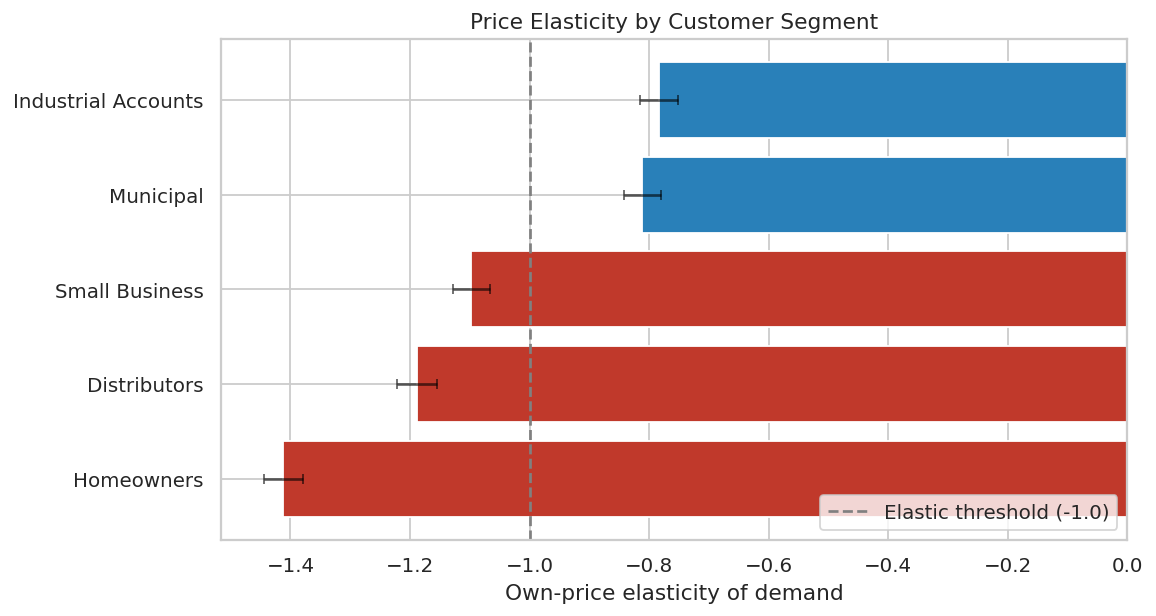

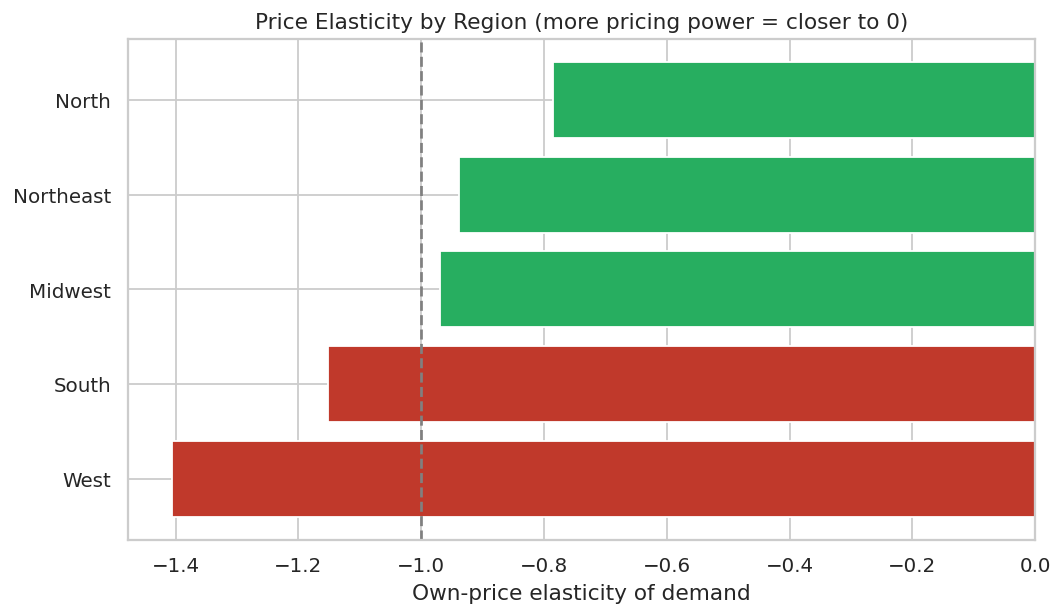

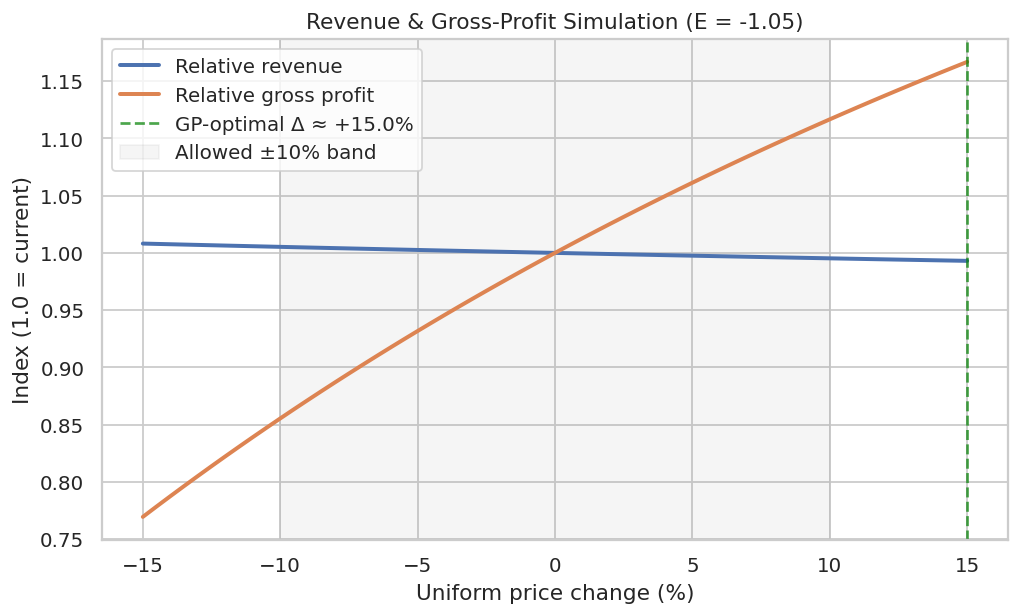

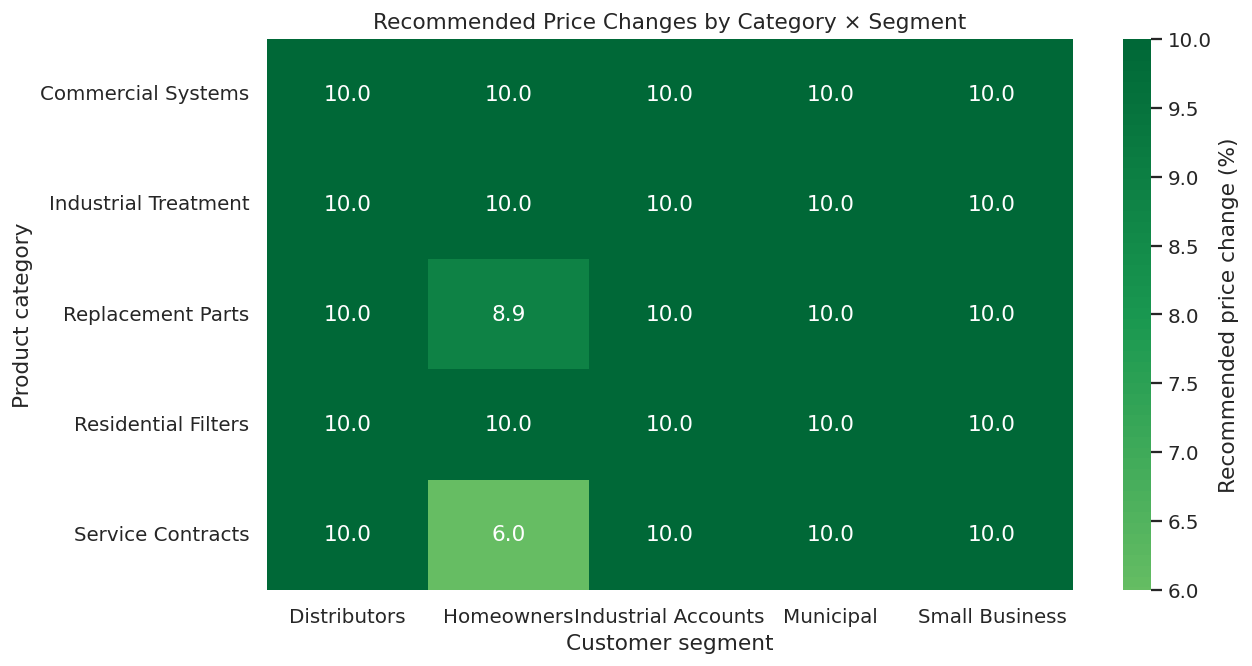

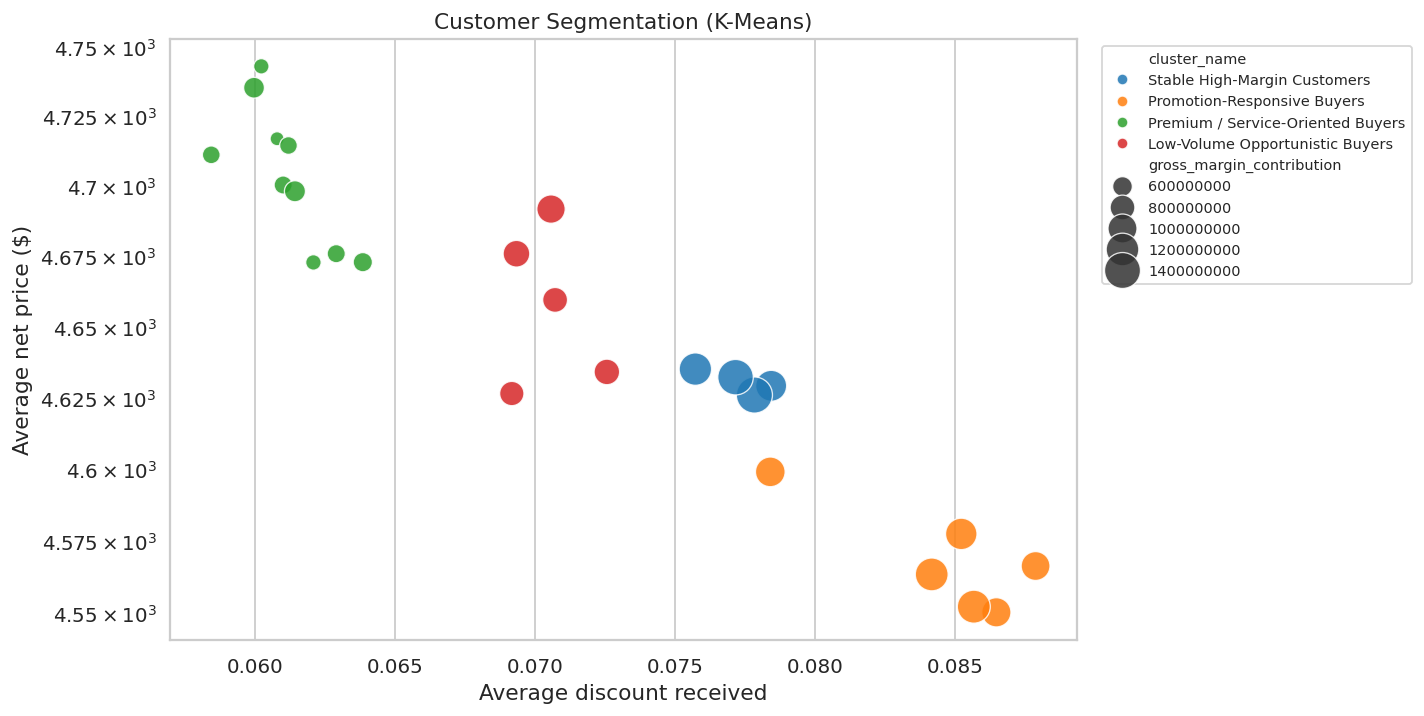

In [8]:
from IPython.display import Image as IPyImage, display
charts = visualization.generate_all_charts(df, results_df, opt_df, profiles, overall['elasticity'])
for k in ['segment','region','simulation','price_changes','clusters']:
    display(IPyImage(filename=charts[k]))

## 6. Business recommendations (generated from actual outputs)

In [9]:
recommendations.build_pricing_recommendations(opt_df)
recommendations.write_segment_elasticity_summary(results_df, profiles)
md = recommendations.write_business_markdown(results_df, seg_region_df, opt_df, overall)
from IPython.display import Markdown
Markdown(md)

[recommendations] wrote /sessions/gifted-magical-shannon/mnt/Pricing/dynamic-pricing-elasticity/outputs/pricing_recommendations.csv
[recommendations] wrote /sessions/gifted-magical-shannon/mnt/Pricing/dynamic-pricing-elasticity/outputs/segment_elasticity_summary.csv
[recommendations] wrote /sessions/gifted-magical-shannon/mnt/Pricing/dynamic-pricing-elasticity/outputs/business_impact_recommendations.md


# Business Impact & Pricing Recommendations — AquaPure Systems

_Generated from model outputs. This project uses synthetic data and anonymized company/product names. It is inspired by a real pricing analytics use case but does not disclose confidential company data, internal systems, customer information, or proprietary business results._

## Executive Summary

Across the analysed portfolio, the estimated **overall own-price elasticity of demand is -1.05** (robust SE 0.01, R² 0.88, n = 27,000). A value of -1.05 means a 1% increase in net price is associated with roughly a 1.05% change in demand, holding seasonality, marketing, competitor pricing, region, product mix and customer segment constant via fixed effects.

Constrained optimization (objective: **gross profit**, price moves capped at ±10%, margin floor 30%) identifies **$2,314,348,255 of incremental gross profit (+10.6%)** over the analysed horizon, against a baseline of $21,734,577,088 gross profit. This comes with a modest revenue trade-off of **-1.4%** ($-688,099,010 on a $50,938,391,226 base) — the expected signature of trading a little volume for materially higher margin, all within governance constraints.

## Where the Pricing Power Is

- **Lowest elasticity (strongest pricing power) segment:** `Industrial Accounts` at **-0.78** — these buyers tolerate price increases with little volume loss.
- **Highest elasticity (most price-sensitive) segment:** `Homeowners` at **-1.41** — protect volume here; use targeted promotions rather than blanket increases.
- **Region with strongest pricing power:** `North` (-0.78); most sensitive region: `West` (-1.41).
- **Category with most pricing power:** `Industrial Treatment` (-0.70); most elastic category: `Residential Filters` (-1.65).

## Recommended Actions

The optimizer produced **55 price-increase**, **0 discount-reduction**, **1 targeted-promotion**, and **0 manual-review** recommendations across 125 product-category × segment × region cells.

### Top 5 gross-profit opportunities

| Category | Segment | Region | Action | Price Δ% | GP impact |
|---|---|---|---|---:|---:|
| Industrial Treatment | Distributors | North | Increase price | +10.0% | $108,254,446 |
| Industrial Treatment | Homeowners | North | Hold price | +10.0% | $91,705,342 |
| Industrial Treatment | Distributors | South | Hold price | +10.0% | $87,212,721 |
| Industrial Treatment | Distributors | Midwest | Hold price | +10.0% | $85,556,913 |
| Industrial Treatment | Small Business | North | Increase price | +10.0% | $83,089,435 |

### Where discounts should be reduced (margin leakage)

- No material discount-reduction cells flagged at current thresholds.

### Where targeted promotions should be used (elastic cells)

- **Service Contracts / Homeowners / West**: elasticity -1.88; a targeted price reduction of -10.0% is expected to lift demand +21.9%.

## Practical Next Steps

**Finance:** lock margin floors per category, fund the price-increase cells above first (lowest execution risk, highest GP), and require model sign-off for any change beyond ±10%.

**Marketing:** redirect promotional budget away from low-elasticity segments (e.g. `Industrial Accounts`) toward the elastic cells listed above, where discounts actually buy incremental volume.

**Sales:** use the recommended price bands as guardrails in quoting tools; escalate manual-review cells rather than discounting on instinct.

## How a Client Can Use This Approach

- **Replace blanket discounting with targeted discounting** driven by measured segment elasticity instead of habit.
- **Protect margin in low-elasticity segments** by holding or raising price where volume is insensitive.
- **Identify product categories with pricing power** and prioritise them for list-price review.
- **Simulate price changes before implementation** using the demand-response equation, avoiding costly live experiments.
- **Align Finance, Marketing, and Sales** around one shared, data-driven set of pricing rules.
- **Build a recurring pricing governance process** — monthly re-estimation, constraint review, and a single approval workflow.


## Notes

The recovered elasticities closely match the latent design embedded in the data generator (e.g. Residential Filters most elastic, Industrial Treatment least), which validates the identification strategy. Run `python main.py` from the project root to reproduce all artifacts including the PDF pitch deck.